In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
%matplotlib inline
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import sklearn
import os
import sys
import time
from tqdm.auto import tqdm
import torch.nn.functional as F
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)


cuda:0


In [20]:
fpath = Path(r"./SONY_daily_data.csv")
df = pd.read_csv(fpath, encoding="utf-8")
df = df.iloc[9064:].reset_index(drop=True)
data = df[["Close", "Volume"]].values


In [ ]:
def calc_peak_valley_5d(df, window=5):
    close = df["Close"].values
    peak5_list = []
    valley5_list = []
    
    for t in range(len(df)):
        end = t + window + 1
        if end >= len(close):
            peak5 = np.nan
            valley5 = np.nan
        else:
            win_close = close[t+1 : t+1+window]
            peak = np.max(win_close)
            valley = np.min(win_close)
            peak5 = (peak - close[t]) / close[t]
            valley5 = (valley - close[t]) / close[t]
        peak5_list.append(peak5)
        valley5_list.append(valley5)
    
    df["peak5"] = peak5_list
    df["valley5"] = valley5_list
    return df
df = calc_peak_valley_5d(df)
def peak_label(p5, v5):
    if pd.isna(p5):
        return "null"
    if p5 >= 0.05:
        return 1
    elif v5 <= -0.05:
        return 1
    else:
        return 0

df["news_label"] = df.apply(lambda x: peak_label(x["peak5"], x["valley5"]), axis=1)


导入新闻

In [22]:
news_path = Path(r"./sony_news_2023.csv")
news_df = pd.read_csv(news_path, encoding="utf-8")
print(news_df.head())


           日期                                  新闻标题
0  2023.12.29  【微分享】索尼中国 第一届 大学生创想大赛 “企”梦索尼 招募正式启动！
1  2023.11.17    索尼宣布悠如音乐（YURU MUSIC）乐器创客马拉松中国赛正式启动
2  2023.11.17  2024年索尼影视娱乐公司庆祝哥伦比亚电影公司百年庆典 揭晓百年纪念标志
3  2023.11.09                    索尼集团发布2023财年第二季度财报
4  2023.11.07           索尼于进博会首发新型环境技术“协生农法”智能协生APP


In [23]:
news_df["date_std"] = pd.to_datetime(news_df["日期"], format="%Y.%m.%d")
news_date_set = set(news_df["date_std"].dt.date)
df["Date_std"] = pd.to_datetime(df["Date"], format="%Y-%m-%d").dt.date
df["has_news"] = df["Date_std"].apply(lambda x: 1 if x in news_date_set else 0)

In [ ]:
temp = df.iloc[1600:2000, [0, -3, -1]]
temp = temp.reset_index(drop=True)
youxiao = temp.iloc[0:189].reset_index(drop=True)

cnt = 0

for i in range(len(youxiao)):
    label = youxiao.iat[i, -1] 
    pred = youxiao.iat[i, -3]   
    
    if (label == 1 and pred != 0) or (label == 0 and pred == 0):
        cnt += 1

print(cnt / 189)

0.19047619047619047


In [ ]:
with open("attention_scores_record.pkl", "rb") as f:
    all_attention_scores = pickle.load(f)
attn_matrix = []
for sample in all_attention_scores:
    # 取5天的
    final_attn = sample[5]  
    attn_matrix.append(final_attn)

# 3. 转成 df
df_attn = pd.DataFrame(attn_matrix)

# 4. 给列起名字
df_attn.columns = [f"attn_day_{i+1}" for i in range(df_attn.shape[1])]

# 5. 查看结果
print("形状：", df_attn.shape)
print(df_attn.head())
avg_attn_list = df_attn.iloc[103:112, 2:12].mean()
print("平均注意力分数：", avg_attn_list)
df_attn = pd.concat([temp, df_attn], axis=1)
df_attn = df_attn.iloc[:, 0:]

形状： (400, 5)
   attn_day_1  attn_day_2  attn_day_3  attn_day_4  attn_day_5
0    0.193651    0.198103    0.200963    0.202990    0.204293
1    0.193655    0.197930    0.201021    0.203060    0.204334
2    0.193514    0.198031    0.201135    0.203138    0.204183
3    0.193656    0.198107    0.201147    0.202921    0.204169
4    0.193728    0.198145    0.200957    0.202927    0.204243
平均注意力分数： attn_day_3    0.201065
attn_day_4    0.203351
attn_day_5    0.204840
dtype: float32


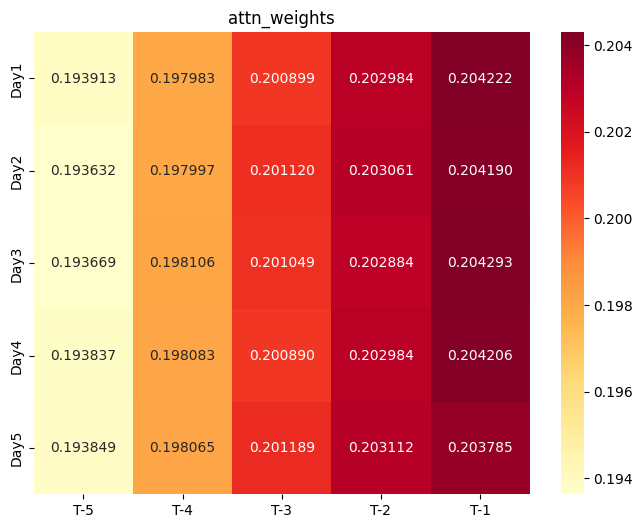

In [29]:
data = df_attn.iloc[91:96, 3:9].astype(float).values
plt.figure(figsize=(8, 6))
sns.heatmap(data, annot=True, fmt='.6f', cmap='YlOrRd', cbar=True,
            xticklabels=['T-5', 'T-4', 'T-3', 'T-2', 'T-1'],
            yticklabels=[f'Day{i}' for i in range(1,6)])
plt.title('attn_weights')
plt.show()